<a href="https://colab.research.google.com/github/Fernanda-Leme/house-price-prediction/blob/main/house-price-prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Comparação de modelos preditivos para prever preços de casas

Este projeto utiliza a base House Prices para comparar o desempenho de dois modelos de regressão: Regressão Linear e Random Forest. Antes da modelagem, os dados são tratados e analisados.

##Biblioteca

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, r2_score

## Base de Dados

In [25]:
df = pd.read_csv('house_prices.csv')

df

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125


In [26]:
print(f'Linhas: {df.shape[0]}')
print(f'Colunas: {df.shape[1]}')

df.info()

Linhas: 1460
Colunas: 81
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-nul

## Valores Nulos

In [27]:
valores_nulos = df.isnull().sum()
valores_nulos = valores_nulos[valores_nulos > 0].sort_values(ascending=False)

porcentagem_nulos = (valores_nulos / len(df) * 100).round(2)

pd.DataFrame({
    'Quantidade': valores_nulos,
    'Porcentagem (%)': porcentagem_nulos
})

,Quantidade,Porcentagem (%)
PoolQC,1453,99.52
MiscFeature,1406,96.30
Alley,1369,93.77
Fence,1179,80.75
MasVnrType,872,59.73
FireplaceQu,690,47.26
LotFrontage,259,17.74
GarageType,81,5.55
GarageYrBlt,81,5.55
GarageFinish,81,5.55


## Tratamento dos valores nulos

Os valores ausentes não devem ser tratados todos da mesma maneira. Primeiro, os metadados foram consultados para identificar colunas em que NA ou None não significam informação desconhecida, mas sim a ausência de determinada característica do imóvel, como garagem, porão, piscina ou lareira.

### Valores em que NA representa ausência de uma característica

O Pandas interpretou esses valores como NaN durante a leitura do arquivo, portanto eles são restaurados como a categoria NA.

In [28]:
colunas_na = [
    'Alley',
    'BsmtQual',
    'BsmtCond',
    'BsmtExposure',
    'BsmtFinType1',
    'BsmtFinType2',
    'FireplaceQu',
    'GarageType',
    'GarageFinish',
    'GarageQual',
    'GarageCond',
    'PoolQC',
    'Fence',
    'MiscFeature'
]

df[colunas_na] = df[colunas_na].fillna('NA')

Nos metadados, None é uma categoria válida de MasVnrType, indicando ausência de revestimento de alvenaria. Os registros em que MasVnrArea está ausente também não possuem tipo de revestimento informado. Por isso, MasVnrType é preenchida com None e a área correspondente com 0.

In [29]:
df['MasVnrType'] = df['MasVnrType'].fillna('None')
df['MasVnrArea'] = df['MasVnrArea'].fillna(0)

- A base possui 81 valores ausentes em GarageYrBlt. A análise conjunta com GarageType, GarageCars e GarageArea mostra que esses registros correspondem a imóveis sem garagem. Portanto, não seria adequado excluir essas casas nem atribuir um ano artificial como 0.
- Para representar essa informação de forma mais apropriada para os modelos, é criada a variável HasGarage (1 = possui garagem; 0 = não possui). Em seguida, GarageYrBlt é transformada em GarageAge, que representa a idade da garagem no ano da venda. Para imóveis sem garagem, GarageAge = 0, enquanto HasGarage = 0 deixa explícito o significado desse valor.

In [30]:
# relação entre GarageYrBlt ausente e ausência de garagem
mask_sem_garagem = df['GarageYrBlt'].isna()

df.loc[mask_sem_garagem, ['GarageType', 'GarageYrBlt', 'GarageCars', 'GarageArea']].head()


,GarageType,GarageYrBlt,GarageCars,GarageArea
39,NA,NaN,0,0
48,NA,NaN,0,0
78,NA,NaN,0,0
88,NA,NaN,0,0
89,NA,NaN,0,0


In [31]:
# 1 = possui garagem | 0 = não possui garagem
df['HasGarage'] = (df['GarageType'] != 'NA').astype(int)

# Idade da garagem no momento da venda
df['GarageAge'] = df['YrSold'] - df['GarageYrBlt']
df.loc[df['HasGarage'] == 0, 'GarageAge'] = 0

# A informação original deixa de ser necessária após a transformação
df = df.drop(columns=['GarageYrBlt'])

## Valores realmente ausentes

- Electrical possui apenas um registro ausente. Como representa uma parcela mínima da base, esse registro é removido.
- LotFrontage possui uma quantidade relevante de valores ausentes. Como é uma variável numérica, será preenchida pela mediana, mas somente depois da divisão entre treino e teste. Assim, a mediana é aprendida apenas com os dados de treino, evitando data leakage.

In [32]:
# Remoção do único registro sem informação de Electrical
df = df.dropna(subset=['Electrical']).copy()

# Conferindo os nulos restantes
nulos_restantes = df.isnull().sum()
nulos_restantes[nulos_restantes > 0]

,0
LotFrontage,259


## Análise Descritiva

In [33]:
df.describe(include='object')

,MSZoning,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,...,GarageType,GarageFinish,GarageQual,GarageCond,PavedDrive,PoolQC,Fence,MiscFeature,SaleType,SaleCondition
count,1459,1459,1459,1459,1459,1459,1459,1459,1459,1459,...,1459,1459,1459,1459,1459,1459,1459,1459,1459,1459
unique,5,2,3,4,4,2,5,3,25,9,...,7,4,6,6,3,4,5,5,9,6
top,RL,Pave,NA,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,...,Attchd,Unf,TA,TA,Y,NA,NA,NA,WD,Normal
freq,1150,1453,1368,924,1310,1458,1051,1381,225,1259,...,870,605,1310,1325,1339,1452,1178,1405,1266,1197


In [34]:
df['SalePrice'].describe()

,SalePrice
count,1459.000000
mean,180930.394791
std,79468.964025
min,34900.000000
25%,129950.000000
50%,163000.000000
75%,214000.000000
max,755000.000000


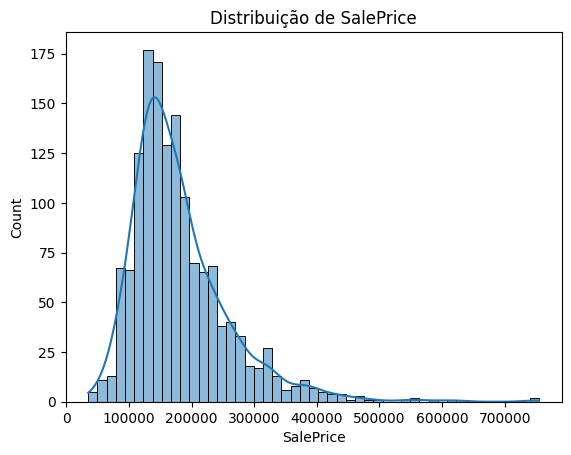

In [35]:
sns.histplot(df['SalePrice'], kde=True)
plt.title('Distribuição de SalePrice')
plt.show()

A distribuição de SalePrice apresenta assimetria positiva, com maior concentração dos imóveis nas faixas de preço mais baixas e uma cauda longa à direita. Isso indica a presença de alguns imóveis com preços significativamente mais altos que a maioria. Como a variável SalePrice será o alvo dos modelos, essa assimetria deve ser considerada durante a modelagem, principalmente na Regressão Linear.

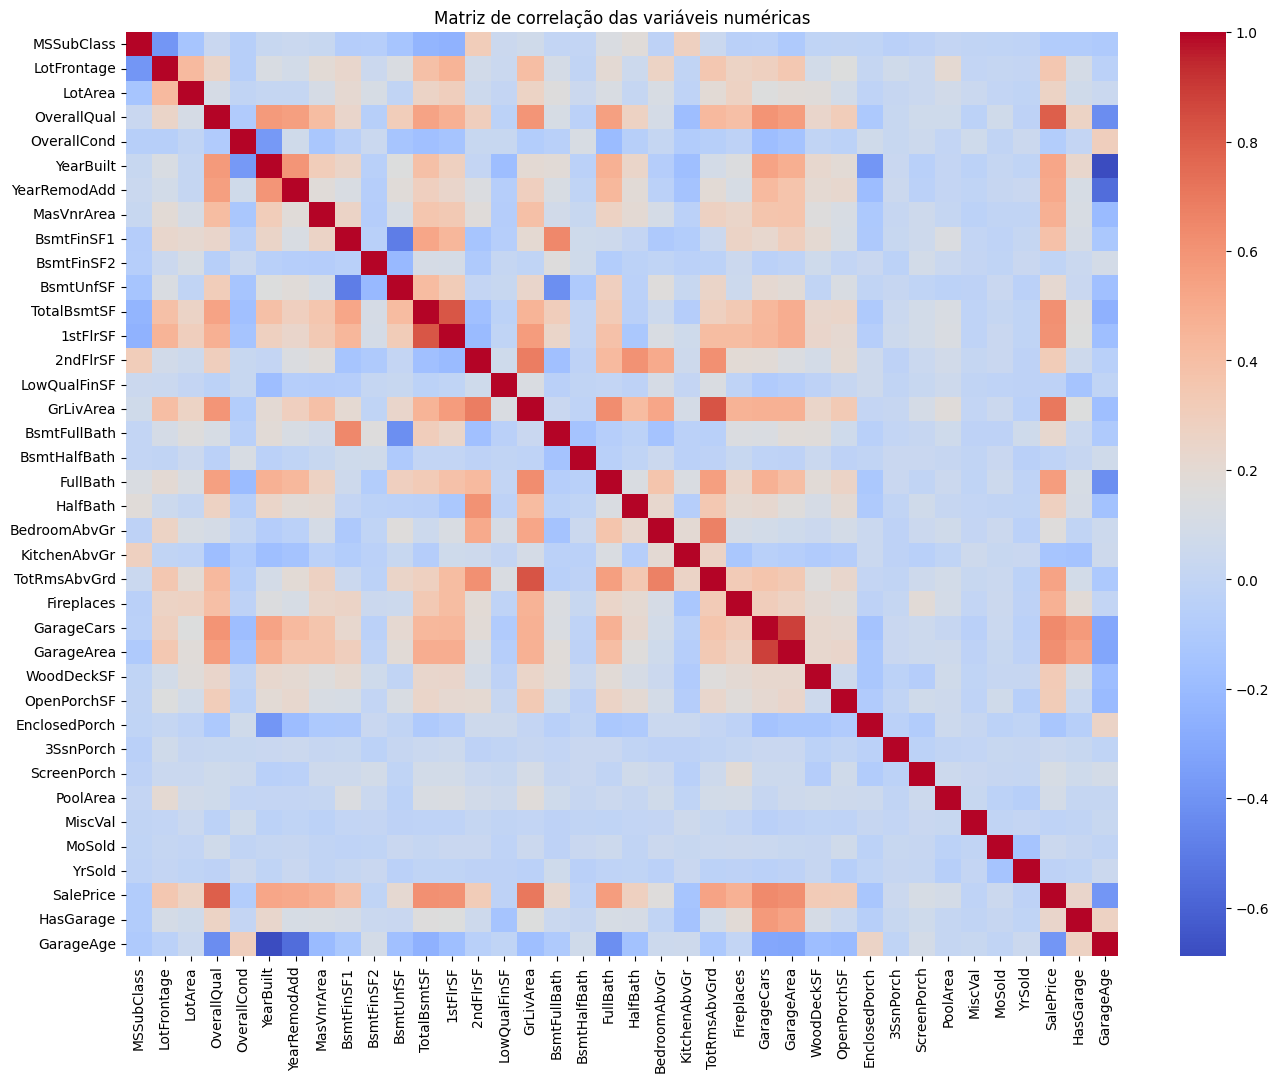

In [36]:
numerical_cols = df.select_dtypes(include=np.number).columns.drop('Id', errors='ignore')
corr_matrix = df[numerical_cols].corr()

plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm')
plt.title('Matriz de correlação das variáveis numéricas')
plt.show()

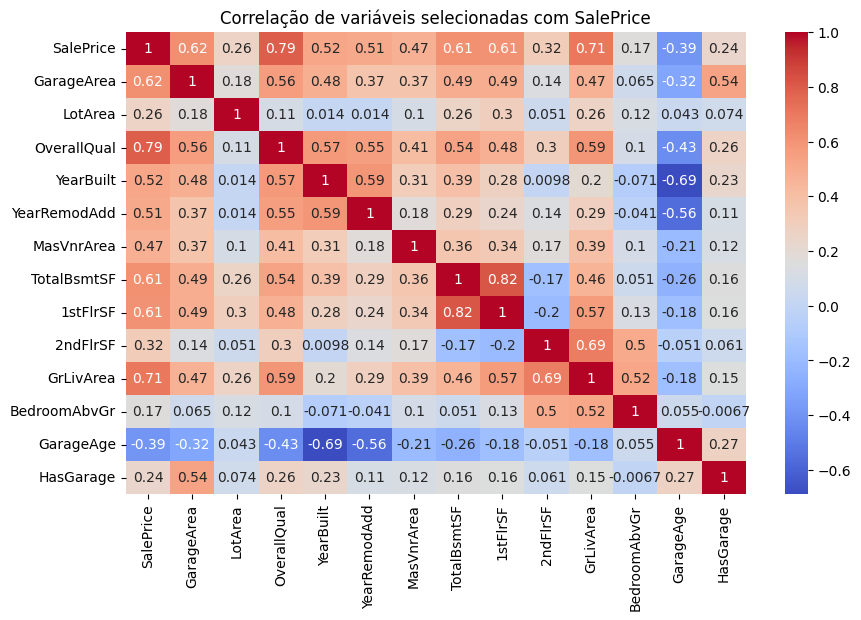

In [37]:
colunas_correlacao = [
    'SalePrice', 'GarageArea', 'LotArea', 'OverallQual', 'YearBuilt',
    'YearRemodAdd', 'MasVnrArea', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF',
    'GrLivArea', 'BedroomAbvGr', 'GarageAge', 'HasGarage'
]

plt.figure(figsize=(10, 6))
sns.heatmap(df[colunas_correlacao].corr(), annot=True, cmap='coolwarm')
plt.title('Correlação de variáveis selecionadas com SalePrice')
plt.show()

- A matriz de correlação mostra que OverallQual (0,79) e GrLivArea (0,71) apresentam as maiores correlações positivas com SalePrice, indicando que a qualidade geral e a área habitável do imóvel possuem forte relação com o preço de venda.

- Outras variáveis como GarageArea, TotalBsmtSF e 1stFlrSF também apresentam correlações relevantes, próximas de 0,60.
Já GarageAge apresenta correlação negativa de -0,39, indicando que garagens mais antigas tendem a estar associadas a menores preços de venda.

## Preparação dos dados para os Modelos

A divisão entre treino e teste é realizada antes da imputação de LotFrontage e do One-Hot Encoding. O pré-processamento é então ajustado somente com o conjunto de treino, reduzindo o risco de data leakage.

In [38]:
X = df.drop(columns=['SalePrice', 'Id'])
y = df['SalePrice']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print('X_train:', X_train.shape)
print('X_test:', X_test.shape)
print('y_train:', y_train.shape)
print('y_test:', y_test.shape)

X_train: (1167, 80)
X_test: (292, 80)
y_train: (1167,)
y_test: (292,)


In [39]:
# Separando as colunas numéricas e categóricas
colunas_numericas = X_train.select_dtypes(include=np.number).columns
colunas_categoricas = X_train.select_dtypes(exclude=np.number).columns

# Criando o pré-processador
preprocessor = ColumnTransformer(
    transformers=[
        ('num', SimpleImputer(strategy='median'), colunas_numericas),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), colunas_categoricas)
    ]
)

print(f'Variáveis numéricas: {len(colunas_numericas)}')
print(f'Variáveis categóricas: {len(colunas_categoricas)}')

Variáveis numéricas: 37
Variáveis categóricas: 43


# Modelo 1 — Regressão Linear

In [ ]:
# Aplicando o pré-processamento
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)

In [41]:
# Treinando o modelo com os dados já tratados
baseline_model = LinearRegression()
baseline_model.fit(X_train_proc, y_train)

y_pred_baseline = baseline_model.predict(X_test_proc)

In [42]:
mape_baseline = mean_absolute_percentage_error(y_test, y_pred_baseline) * 100
print(f"MAPE do Modelo Baseline (Regressão Linear): {mape_baseline:.2f}%")

MAPE do Modelo Baseline (Regressão Linear): 12.38%


Em média, as previsões do modelo se desviam em cerca de 12,38% do valor real de venda.

In [43]:
mae_baseline = mean_absolute_error(y_test, y_pred_baseline)
r2_baseline = r2_score(y_test, y_pred_baseline)

mae_baseline, r2_baseline

(19144.746202116206, 0.8762509805418567)

Em média, as previsões erram cerca de R$19.145 para mais ou para menos em relação ao valor real (MAE). O R² de 0,876 indica que o modelo consegue explicar aproximadamente 87,6% da variação nos preços de venda.

# Modelo 2 — Random Forest

In [44]:
modelo_rf = RandomForestRegressor(random_state=42)
modelo_rf.fit(X_train_proc, y_train)

y_pred_rf = modelo_rf.predict(X_test_proc)

In [45]:
mape_rf = mean_absolute_percentage_error(y_test, y_pred_rf) * 100
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"MAPE do Random Forest (baseline): {mape_rf:.2f}%")
mae_rf, r2_rf

MAPE do Random Forest (baseline): 11.01%


(17418.323904109588, 0.8902349169258327)

## Comparação Final do Desempenho dos Modelos

In [46]:
comparacao = pd.DataFrame({
    'Modelo': ['Regressão Linear', 'Random Forest'],
    'MAE': [mae_baseline, mae_rf],
    'MAPE (%)': [mape_baseline, mape_rf],
    'R2': [r2_baseline, r2_rf]
})

comparacao

,Modelo,MAE,MAPE (%),R2
0,Regressão Linear,19144.746202,12.376225,0.876251
1,Random Forest,17418.323904,11.010626,0.890235


###Conclusão

O Random Forest superou a Regressão Linear nas três métricas: menor MAPE (11,01% contra 12,38%), menor MAE (R\$ 17.418 contra R\$ 19.145) e maior R² (0,890 contra 0,876).

Isso indica que o Random Forest captura melhor as relações não-lineares entre as variáveis e o preço de venda, algo que a Regressão Linear, por assumir relações lineares entre as variáveis, não consegue representar tão bem.

Ainda assim, a diferença de desempenho entre os dois modelos não é muito grande, o que mostra que a Regressão Linear também é uma baseline razoável para este problema.